# Proyek Akhir - Prediksi Risiko Dropout Mahasiswa Jaya Jaya Institut

Notebook ini memuat alur end-to-end proyek data science:

1. Business understanding  
2. Data understanding  
3. Exploratory data analysis  
4. Data preparation  
5. Modeling  
6. Evaluation  
7. Simpan artefak model

## Business Understanding

Jaya Jaya Institut ingin mendeteksi mahasiswa yang berpotensi dropout sedini mungkin agar dapat diberikan intervensi khusus.  
Fokus bisnis proyek ini adalah membangun **early warning system** yang:

- mendeteksi risiko dropout,
- menjelaskan faktor utama yang relevan,
- dan mendukung monitoring lewat dashboard.

In [1]:
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / "data" / "data.csv"
MODEL_DIR = BASE_DIR / "model"
MODEL_DIR.mkdir(exist_ok=True, parents=True)

pd.set_option("display.max_columns", None)

## Load Data

In [2]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (4424, 37)


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Quality Check

In [3]:
quality_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_values": df.isna().sum(),
    "n_unique": df.nunique()
})
quality_summary.head(10)

,dtype,missing_values,n_unique
Marital_status,int64,0,6
Application_mode,int64,0,18
Application_order,int64,0,8
Course,int64,0,17
Daytime_evening_attendance,int64,0,2
Previous_qualification,int64,0,17
Previous_qualification_grade,float64,0,101
Nacionality,int64,0,21
Mothers_qualification,int64,0,29
Fathers_qualification,int64,0,34


In [4]:
print("Jumlah duplikat:", df.duplicated().sum())
print("\nDistribusi Status:")
print(df["Status"].value_counts())

Jumlah duplikat: 0

Distribusi Status:
Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


## Exploratory Data Analysis

EDA difokuskan pada pola yang paling relevan dengan risiko dropout, terutama dari sisi:

- distribusi target,
- faktor finansial,
- usia masuk,
- performa akademik semester awal.

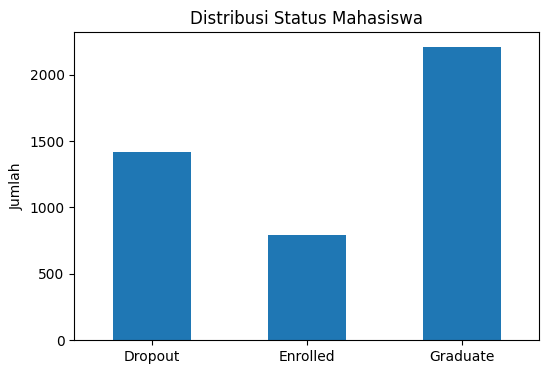

In [5]:
status_counts = df["Status"].value_counts().reindex(["Dropout", "Enrolled", "Graduate"]).fillna(0)

plt.figure(figsize=(6,4))
status_counts.plot(kind="bar")
plt.title("Distribusi Status Mahasiswa")
plt.xlabel("")
plt.ylabel("Jumlah")
plt.xticks(rotation=0)
plt.show()

In [6]:
finance_insight = pd.DataFrame({
    "Dropout rate": [
        df.loc[df["Tuition_fees_up_to_date"] == 0, "Status"].eq("Dropout").mean(),
        df.loc[df["Debtor"] == 1, "Status"].eq("Dropout").mean(),
        df.loc[df["Scholarship_holder"] == 0, "Status"].eq("Dropout").mean(),
    ],
}, index=["Tuition not up to date", "Debtor", "No scholarship"])

finance_insight

,Dropout rate
Tuition not up to date,0.865530
Debtor,0.620278
No scholarship,0.387068


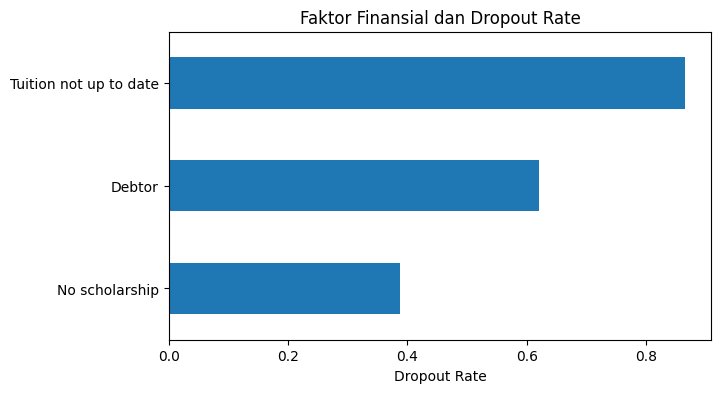

In [7]:
finance_insight.sort_values("Dropout rate").plot(kind="barh", figsize=(7,4), legend=False)
plt.title("Faktor Finansial dan Dropout Rate")
plt.xlabel("Dropout Rate")
plt.ylabel("")
plt.show()

In [8]:
eda_df = df.copy()
eda_df["Age_group"] = pd.cut(
    eda_df["Age_at_enrollment"],
    bins=[0, 18, 21, 25, 30, 100],
    labels=["<=18", "19-21", "22-25", "26-30", ">30"]
)

age_dropout = eda_df.groupby("Age_group", observed=False)["Status"].apply(lambda s: (s == "Dropout").mean())
age_dropout

Age_group
<=18     0.194044
19-21    0.236354
22-25    0.399209
26-30    0.597911
>30      0.536254
Name: Status, dtype: float64

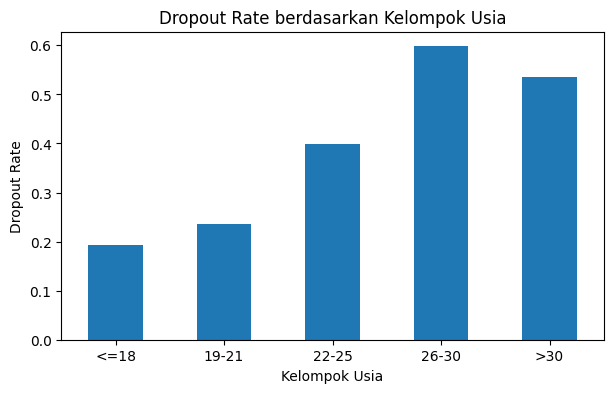

In [9]:
age_dropout.plot(kind="bar", figsize=(7,4))
plt.title("Dropout Rate berdasarkan Kelompok Usia")
plt.xlabel("Kelompok Usia")
plt.ylabel("Dropout Rate")
plt.xticks(rotation=0)
plt.show()

In [10]:
academic_summary = df.groupby("Status")[
    [
        "Curricular_units_1st_sem_approved",
        "Curricular_units_2nd_sem_approved",
        "Curricular_units_1st_sem_grade",
        "Curricular_units_2nd_sem_grade",
    ]
].mean().round(2)

academic_summary

,Curricular_units_1st_sem_approved,Curricular_units_2nd_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_2nd_sem_grade
Status,,,,
Dropout,2.55,1.94,7.26,5.90
Enrolled,4.32,4.06,11.13,11.12
Graduate,6.23,6.18,12.64,12.70


## Data Preparation

Target untuk kebutuhan early warning diubah menjadi biner:

- `1` = Dropout
- `0` = Enrolled atau Graduate

In [11]:
df["Dropout_Risk"] = (df["Status"] == "Dropout").astype(int)

X = df.drop(columns=["Status", "Dropout_Risk"])
y = df["Dropout_Risk"]

num_cols = [
    "Previous_qualification_grade",
    "Admission_grade",
    "Age_at_enrollment",
    "Curricular_units_1st_sem_credited",
    "Curricular_units_1st_sem_enrolled",
    "Curricular_units_1st_sem_evaluations",
    "Curricular_units_1st_sem_approved",
    "Curricular_units_1st_sem_grade",
    "Curricular_units_1st_sem_without_evaluations",
    "Curricular_units_2nd_sem_credited",
    "Curricular_units_2nd_sem_enrolled",
    "Curricular_units_2nd_sem_evaluations",
    "Curricular_units_2nd_sem_approved",
    "Curricular_units_2nd_sem_grade",
    "Curricular_units_2nd_sem_without_evaluations",
    "Unemployment_rate",
    "Inflation_rate",
    "GDP",
]

cat_cols = [col for col in X.columns if col not in num_cols]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            num_cols,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore")),
            ]),
            cat_cols,
        ),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train.shape, X_test.shape

((3539, 36), (885, 36))

## Modeling

In [12]:
candidate_models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

comparison_rows = []
for name, model in candidate_models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])
    scores = cross_validate(
        pipe,
        X,
        y,
        cv=cv,
        scoring=["roc_auc", "accuracy", "precision", "recall", "f1"],
        n_jobs=1,
    )
    comparison_rows.append({
        "Model": name,
        "ROC_AUC": np.mean(scores["test_roc_auc"]),
        "Accuracy": np.mean(scores["test_accuracy"]),
        "Precision": np.mean(scores["test_precision"]),
        "Recall": np.mean(scores["test_recall"]),
        "F1": np.mean(scores["test_f1"]),
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values("ROC_AUC", ascending=False).reset_index(drop=True)
comparison_df.round(3)

,Model,ROC_AUC,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.921,0.863,0.768,0.822,0.794
1,Random Forest,0.919,0.874,0.835,0.758,0.794


Model final yang dipilih adalah **Logistic Regression** karena:

- ROC-AUC paling tinggi,
- recall cukup kuat untuk kebutuhan early warning,
- lebih ringan untuk deployment,
- dan lebih mudah dijelaskan ke user bisnis.

In [13]:
final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced")),
])

final_pipeline.fit(X_train, y_train)
proba = final_pipeline.predict_proba(X_test)[:, 1]

threshold = 0.45
pred = (proba >= threshold).astype(int)

metrics = pd.Series({
    "ROC_AUC": roc_auc_score(y_test, proba),
    "Accuracy": accuracy_score(y_test, pred),
    "Precision": precision_score(y_test, pred),
    "Recall": recall_score(y_test, pred),
    "F1": f1_score(y_test, pred),
})

metrics.round(3)

ROC_AUC      0.931
Accuracy     0.864
Precision    0.755
Recall       0.856
F1           0.802
dtype: float64

In [14]:
cm = confusion_matrix(y_test, pred)
cm

array([[522,  79],
       [ 41, 243]])

In [15]:
print(classification_report(y_test, pred, target_names=["Non-Dropout", "Dropout"]))

              precision    recall  f1-score   support

 Non-Dropout       0.93      0.87      0.90       601
     Dropout       0.75      0.86      0.80       284

    accuracy                           0.86       885
   macro avg       0.84      0.86      0.85       885
weighted avg       0.87      0.86      0.87       885



## Fitur yang Paling Berpengaruh

In [16]:
perm = permutation_importance(
    final_pipeline,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
    n_jobs=1,
)

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": perm.importances_mean,
}).sort_values("importance", ascending=False)

importance_df.head(10)

,feature,importance
30,Curricular_units_2nd_sem_approved,0.193098
24,Curricular_units_1st_sem_approved,0.060285
28,Curricular_units_2nd_sem_enrolled,0.030609
16,Tuition_fees_up_to_date,0.028362
33,Unemployment_rate,0.009467
27,Curricular_units_2nd_sem_credited,0.009194
3,Course,0.007961
22,Curricular_units_1st_sem_enrolled,0.004948
21,Curricular_units_1st_sem_credited,0.004716
31,Curricular_units_2nd_sem_grade,0.004693


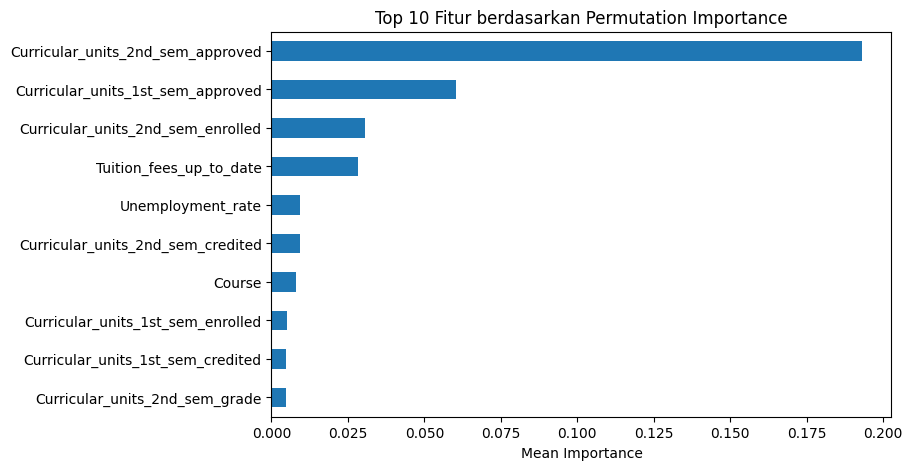

In [17]:
importance_df.head(10).sort_values("importance").plot(
    kind="barh",
    x="feature",
    y="importance",
    figsize=(8,5),
    legend=False,
)
plt.title("Top 10 Fitur berdasarkan Permutation Importance")
plt.xlabel("Mean Importance")
plt.ylabel("")
plt.show()

## Simpan Artefak Model

In [18]:
joblib.dump(final_pipeline, MODEL_DIR / "dropout_pipeline.joblib")

metrics_dict = {
    "selected_model": "Logistic Regression",
    "threshold": threshold,
    "roc_auc": float(metrics["ROC_AUC"]),
    "accuracy": float(metrics["Accuracy"]),
    "precision": float(metrics["Precision"]),
    "recall": float(metrics["Recall"]),
    "f1_score": float(metrics["F1"]),
    "confusion_matrix": cm.tolist(),
}

with open(MODEL_DIR / "model_metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics_dict, f, indent=2)

print("Artefak model tersimpan di folder model/.")

Artefak model tersimpan di folder model/.


## Conclusion Singkat

Dari proyek ini terlihat bahwa risiko dropout paling kuat berkaitan dengan:

- performa akademik semester awal,
- keterlambatan/ketidakrapihan pembayaran biaya kuliah,
- status debtor,
- dan karakteristik tertentu pada kelompok mahasiswa.

Model yang dibangun cukup layak untuk dipakai sebagai **alat bantu prioritisasi intervensi**.  
Tetap perlu diingat, hasil model bukan keputusan final. Validasi oleh pihak akademik tetap diperlukan.